# Kernel & Geometry Analysis: Finding a Geometry-Preserving Initialization

This notebook investigates **three questions** from the mathematical analysis:

1. **Does orthogonal initialization prevent geometric collapse?**  
   Theory predicts NO — same expected kernel K(α) as Gaussian (same per-row marginal).  
   We verify empirically with the new geometry metrics.

2. **Can negative bias reduce the kernel distortion?**  
   We numerically compute the biased ReLU kernel K_β(α) and find the β* that  
   minimizes the normalized distortion D_β(α) = K_β(α)/K_β(0) - cos(α).

3. **What structure does the kernel_preserving optimizer find?**  
   We analyze the optimized W matrices to reverse-engineer a closed-form initializer.

In [1]:
# Setup
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import math
from scipy.stats import norm as normal_dist
from scipy.integrate import dblquad

from rp_study.data.loaders import get_data_loader
from rp_study.projections import multi_layer_rp_with_init
from rp_study.analysis.geometry_metrics import evaluate_geometry
from rp_study.analysis.kernel import k_alpha
from rp_study.models.initializers import initialize_layer, list_initializers
from rp_study.config import ExperimentConfig

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Available initializers: {list_initializers()}')

Device: cpu
Available initializers: ['he', 'row_centered_he', 'row_centered_he_var_adj', 'partial_centered_he', 'orthogonal_he', 'orthogonal_tuned', 'centered_with_dc_he', 'custom_variance', 'xavier', 'uniform_he', 'orthogonal', 'kernel_preserving', 'angle_preserving', 'row_centered_final', 'row_centered_layer_balanced', 'row_centered_forward_balanced']


In [2]:
# ====== CONFIGURATION ======

SEED = 42
DATASET = 'fashion_mnist'
DATA_DIR = '../data'
N_SAMPLES = 2000  # for geometry tests

# Depths to test (20 layers is sufficient to see collapse trends)
DEPTHS = [5, 10, 15, 20]

# Initializers for geometry comparison
GEOMETRY_INITS = [
    'he',
    'orthogonal_he',
    'orthogonal_tuned',
    'row_centered_he_var_adj',
    'kernel_preserving',
]

# Load data
X_all, y_all = get_data_loader(
    dataset_name=DATASET, data_dir=DATA_DIR, train=True,
    flatten=True, as_numpy=True,
)
# Subsample for speed
rng = np.random.RandomState(SEED)
idx = rng.choice(len(X_all), N_SAMPLES, replace=False)
X_data = X_all[idx]
y_data = y_all[idx]

print(f'Data shape: {X_data.shape}, Labels: {len(np.unique(y_data))} classes')
print(f'Depths: {DEPTHS}')
print(f'Initializers: {GEOMETRY_INITS}')

Data shape: (2000, 784), Labels: 10 classes
Depths: [5, 10, 15, 20]
Initializers: ['he', 'orthogonal_he', 'orthogonal_tuned', 'row_centered_he_var_adj', 'kernel_preserving']


## Section 1: Deep Geometry Comparison

**Theoretical prediction** (§0.2 of plan): Orthogonal initialization has the same  
expected kernel K(α) as Gaussian initialization, because each row's marginal  
distribution on the sphere is the same. Orthogonal only reduces variance (better  
concentration), not the systematic bias D(α) = (1/π)[sin α - α cos α] > 0.

**Test**: Run geometry metrics at depths [5, 10, 20, 30, 50] for he, orthogonal_he,  
orthogonal_tuned, row_centered_he_var_adj, and kernel_preserving.

In [3]:
# Run geometry evaluation for all initializers at all depths
geometry_results = {}  # (init, depth) -> metrics dict

for init in GEOMETRY_INITS:
    for depth in DEPTHS:
        print(f'  {init}, depth={depth}...', end=' ')
        
        # Reset seed for fair comparison
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        
        X_proj = multi_layer_rp_with_init(
            X_data, depth, init_strategy=init,
            seed=SEED, device=DEVICE,
        )
        
        # Check for numerical issues (overflow at deep layers)
        if not np.all(np.isfinite(X_proj)):
            print(f'OVERFLOW (NaN/Inf detected)')
            geometry_results[(init, depth)] = {
                'knn_accuracy': float('nan'),
                'distance_correlation': float('nan'),
                'effective_dim': float('nan'),
                'effective_dim_original': float('nan'),
            }
            continue
        
        metrics = evaluate_geometry(X_data, X_proj, y_data, k=5, seed=SEED)
        geometry_results[(init, depth)] = metrics
        
        print(f'kNN={metrics["knn_accuracy"]:.3f}, '
              f'dist_corr={metrics["distance_correlation"]:.3f}, '
              f'eff_dim={metrics["effective_dim"]:.1f}')

print('\nDone!')

  he, depth=5... kNN=0.736, dist_corr=0.843, eff_dim=19.7
  he, depth=10... kNN=0.710, dist_corr=0.767, eff_dim=13.0
  he, depth=15... kNN=0.673, dist_corr=0.690, eff_dim=7.5
  he, depth=20... kNN=0.639, dist_corr=0.654, eff_dim=5.8
  orthogonal_he, depth=5... kNN=0.755, dist_corr=0.875, eff_dim=26.6
  orthogonal_he, depth=10... kNN=0.724, dist_corr=0.728, eff_dim=17.5
  orthogonal_he, depth=15... kNN=0.696, dist_corr=0.670, eff_dim=12.2
  orthogonal_he, depth=20... kNN=0.662, dist_corr=0.600, eff_dim=7.3
  orthogonal_tuned, depth=5... kNN=0.755, dist_corr=0.875, eff_dim=26.6
  orthogonal_tuned, depth=10... kNN=0.724, dist_corr=0.728, eff_dim=17.5
  orthogonal_tuned, depth=15... kNN=0.696, dist_corr=0.670, eff_dim=12.2
  orthogonal_tuned, depth=20... kNN=0.662, dist_corr=0.600, eff_dim=7.3
  row_centered_he_var_adj, depth=5... kNN=0.717, dist_corr=0.743, eff_dim=136.2
  row_centered_he_var_adj, depth=10... kNN=0.482, dist_corr=0.476, eff_dim=289.7
  row_centered_he_var_adj, depth=15...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)
/Users/itayofer/Thesis/Thesis/notebooks/../src/rp_study/analysis/geometry_metrics.py:109: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(dist_orig, dist_proj)
/Users/itayofer/Thesis/Thesis/notebooks/../src/rp_study/analysis/geometry_metrics.py:141: RuntimeWarning: invalid value encountered in scalar divide
  relative_variation = centered_norm / data_norm


kNN=0.100, dist_corr=nan, eff_dim=1.0

Done!


In [4]:
# Summary table
print(f'{"Initializer":>30s}', end='')
for d in DEPTHS:
    print(f'  {d:>4d}L', end='')
print()
print('-' * (30 + 7 * len(DEPTHS)))

for metric_name, metric_label in [
    ('knn_accuracy', 'k-NN Accuracy'),
    ('distance_correlation', 'Dist Correlation'),
    ('effective_dim', 'Eff. Dimension'),
]:
    print(f'\n--- {metric_label} ---')
    for init in GEOMETRY_INITS:
        print(f'{init:>30s}', end='')
        for depth in DEPTHS:
            val = geometry_results[(init, depth)][metric_name]
            if metric_name == 'effective_dim':
                print(f'  {val:>5.1f}', end='')
            else:
                print(f'  {val:>.3f}', end='')
        print()

                   Initializer     5L    10L    15L    20L
----------------------------------------------------------

--- k-NN Accuracy ---
                            he  0.736  0.710  0.673  0.639
                 orthogonal_he  0.755  0.724  0.696  0.662
              orthogonal_tuned  0.755  0.724  0.696  0.662
       row_centered_he_var_adj  0.717  0.482  0.186  0.110
             kernel_preserving  0.738  0.626  0.536  0.100

--- Dist Correlation ---
                            he  0.843  0.767  0.690  0.654
                 orthogonal_he  0.875  0.728  0.670  0.600
              orthogonal_tuned  0.875  0.728  0.670  0.600
       row_centered_he_var_adj  0.743  0.476  0.363  0.349
             kernel_preserving  0.722  0.598  0.524  nan

--- Eff. Dimension ---
                            he   19.7   13.0    7.5    5.8
                 orthogonal_he   26.6   17.5   12.2    7.3
              orthogonal_tuned   26.6   17.5   12.2    7.3
       row_centered_he_var_adj  136.2  289.7

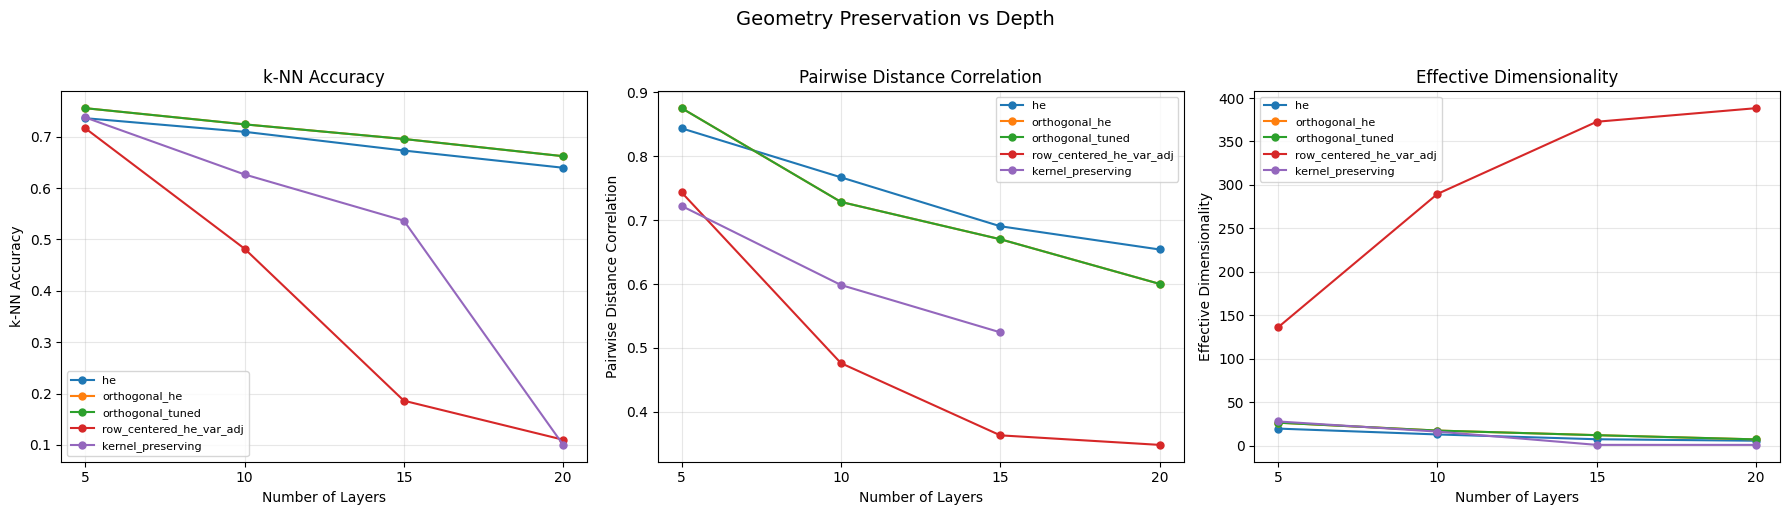

In [5]:
# Plot k-NN accuracy vs depth for each initializer
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for metric_idx, (metric_name, metric_label) in enumerate([
    ('knn_accuracy', 'k-NN Accuracy'),
    ('distance_correlation', 'Pairwise Distance Correlation'),
    ('effective_dim', 'Effective Dimensionality'),
]):
    ax = axes[metric_idx]
    for init in GEOMETRY_INITS:
        vals = [geometry_results[(init, d)][metric_name] for d in DEPTHS]
        ax.plot(DEPTHS, vals, 'o-', label=init, markersize=5)
    
    ax.set_xlabel('Number of Layers')
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(DEPTHS)

plt.suptitle('Geometry Preservation vs Depth', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

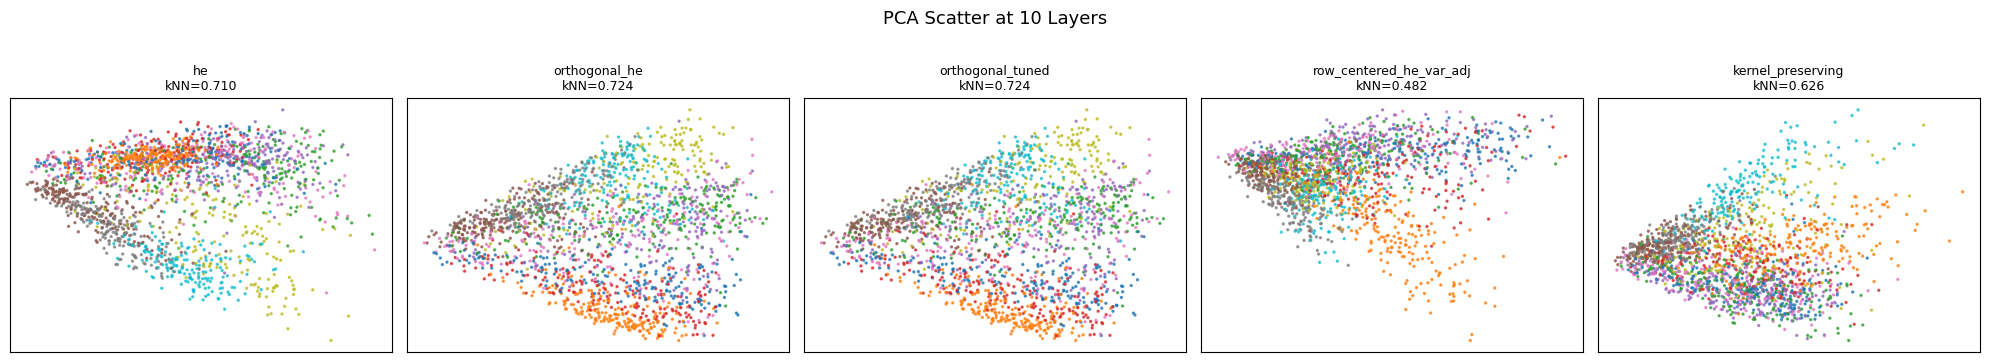

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:765: RuntimeWarning: overflow encountered in square
  self.explained_variance_ = (S**2) / (n_samples - 1)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:776: RuntimeWarning: overflow encountered in square
  X_centered **= 2
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:783: RuntimeWarning: invalid value en

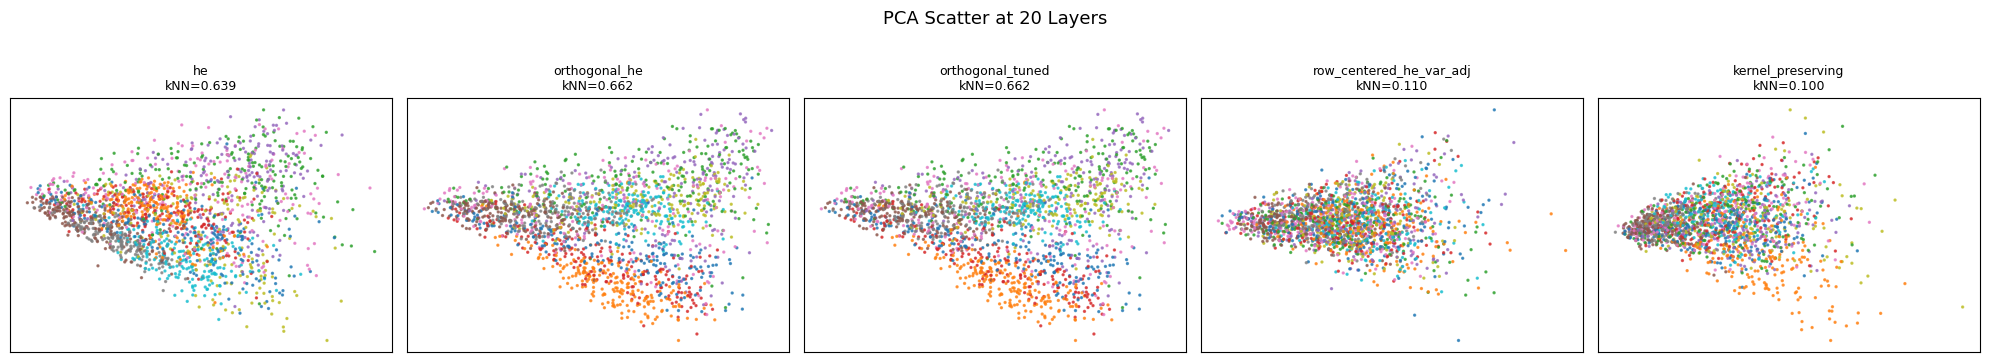

In [6]:
# PCA scatter plots at depth=10 and depth=20 for visual comparison
from sklearn.decomposition import PCA

for depth in [10, 20]:
    fig, axes = plt.subplots(1, len(GEOMETRY_INITS), figsize=(4 * len(GEOMETRY_INITS), 3.5))
    
    for i, init in enumerate(GEOMETRY_INITS):
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        
        X_proj = multi_layer_rp_with_init(
            X_data, depth, init_strategy=init,
            seed=SEED, device=DEVICE,
        )
        
        # Check for NaN/Inf (can happen with numerical overflow)
        if not np.all(np.isfinite(X_proj)):
            axes[i].text(0.5, 0.5, 'NaN/Inf\n(numerical overflow)',
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{init}\n(overflow)', fontsize=9)
        else:
            pca = PCA(n_components=2)
            X_vis = pca.fit_transform(X_proj)
            axes[i].scatter(X_vis[:, 0], X_vis[:, 1], s=2, c=y_data, cmap='tab10', alpha=0.7)
            knn = geometry_results.get((init, depth), {}).get('knn_accuracy', float('nan'))
            axes[i].set_title(f'{init}\nkNN={knn:.3f}', fontsize=9)
        axes[i].set_xticks([])
        axes[i].set_yticks([])
    
    plt.suptitle(f'PCA Scatter at {depth} Layers', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## Section 2: Biased ReLU Kernel K_β(α)

**From §0.4 of plan**: With bias b < 0 (normalized: β = b/σ), the pre-activation is  
z = w^T x + b ~ N(b, σ²). The biased kernel is:

$$K_\beta(\alpha) = E[\text{ReLU}(u + \beta) \cdot \text{ReLU}(v + \beta)]$$

where $(u, v) \sim N(0, [[1, \rho], [\rho, 1]])$ and $\rho = \cos(\alpha)$.

We compute this numerically via Monte Carlo and find β* that minimizes  
the normalized distortion $D_\beta(\alpha) = K_\beta(\alpha)/K_\beta(0) - \cos(\alpha)$.

In [7]:
def biased_relu_kernel_mc(alpha, beta, n_mc=500_000, seed=42):
    """Compute K_beta(alpha) via Monte Carlo.
    
    K_beta(alpha) = E[ReLU(u + beta) * ReLU(v + beta)]
    where (u, v) ~ N(0, [[1, rho], [rho, 1]]), rho = cos(alpha).
    
    Args:
        alpha: Input angle (scalar or array)
        beta: Normalized bias (scalar)
        n_mc: Number of MC samples
        seed: Random seed
    
    Returns:
        K_beta(alpha) value(s)
    """
    rng = np.random.RandomState(seed)
    alpha = np.atleast_1d(alpha)
    results = np.zeros_like(alpha, dtype=float)
    
    # Generate standard normal samples
    z1 = rng.randn(n_mc)
    z2 = rng.randn(n_mc)
    
    for i, a in enumerate(alpha):
        rho = np.cos(a)
        # Bivariate normal: u = z1, v = rho*z1 + sqrt(1-rho^2)*z2
        u = z1
        v = rho * z1 + np.sqrt(max(1 - rho**2, 0)) * z2
        
        # Apply ReLU with bias
        relu_u = np.maximum(0, u + beta)
        relu_v = np.maximum(0, v + beta)
        
        results[i] = np.mean(relu_u * relu_v)
    
    return results


# Test: beta=0 should recover standard K(alpha)
test_alpha = np.linspace(0.1, np.pi - 0.1, 20)
k_mc = biased_relu_kernel_mc(test_alpha, beta=0.0)
k_theory = k_alpha(test_alpha)

print('Verification: K_0(alpha) should match analytical K(alpha)')
print(f'Max absolute error: {np.max(np.abs(k_mc - k_theory)):.5f}')
print(f'Max relative error: {np.max(np.abs(k_mc - k_theory) / k_theory):.4f}')

Verification: K_0(alpha) should match analytical K(alpha)
Max absolute error: 0.00110
Max relative error: 0.0130


In [8]:
# Compute K_beta(alpha) for a range of beta values
BETA_VALUES = [0.0, -0.25, -0.5, -0.75, -1.0, -1.5, -2.0]
alpha_grid = np.linspace(0.01, np.pi - 0.01, 200)
cos_alpha = np.cos(alpha_grid)

kernel_data = {}  # beta -> {k_values, normalized, distortion}

for beta in BETA_VALUES:
    k_vals = biased_relu_kernel_mc(alpha_grid, beta=beta, n_mc=1_000_000)
    k_at_0 = biased_relu_kernel_mc(np.array([0.0]), beta=beta, n_mc=1_000_000)[0]
    
    # Normalized kernel (output cosine similarity)
    normalized = k_vals / k_at_0
    
    # Distortion: how far from identity (cos(alpha))
    distortion = normalized - cos_alpha
    
    # Integrated distortion (L2)
    integrated_dist = np.trapezoid(distortion**2, alpha_grid)
    
    # Survival rate: P(u + beta > 0) = P(u > -beta) = Phi(beta)
    survival = normal_dist.cdf(beta)
    
    kernel_data[beta] = {
        'k_values': k_vals,
        'k_at_0': k_at_0,
        'normalized': normalized,
        'distortion': distortion,
        'integrated_distortion': integrated_dist,
        'survival_rate': survival,
    }
    
    print(f'β={beta:>5.2f}: K(0)={k_at_0:.4f}, '
          f'∫D²={integrated_dist:.5f}, '
          f'survival={survival:.3f}, '
          f'max|D|={np.max(np.abs(distortion)):.4f}')

print(f'\nReference: standard He (β=0) distortion = {kernel_data[0.0]["integrated_distortion"]:.5f}')

β= 0.00: K(0)=0.4988, ∫D²=0.91205, survival=0.500, max|D|=1.0000
β=-0.25: K(0)=0.3288, ∫D²=0.84641, survival=0.401, max|D|=1.0000
β=-0.50: K(0)=0.2089, ∫D²=0.81129, survival=0.309, max|D|=1.0000
β=-0.75: K(0)=0.1277, ∫D²=0.79633, survival=0.227, max|D|=1.0000
β=-1.00: K(0)=0.0749, ∫D²=0.79506, survival=0.159, max|D|=1.0000
β=-1.50: K(0)=0.0226, ∫D²=0.81811, survival=0.067, max|D|=1.0000
β=-2.00: K(0)=0.0057, ∫D²=0.85925, survival=0.023, max|D|=1.0000

Reference: standard He (β=0) distortion = 0.91205


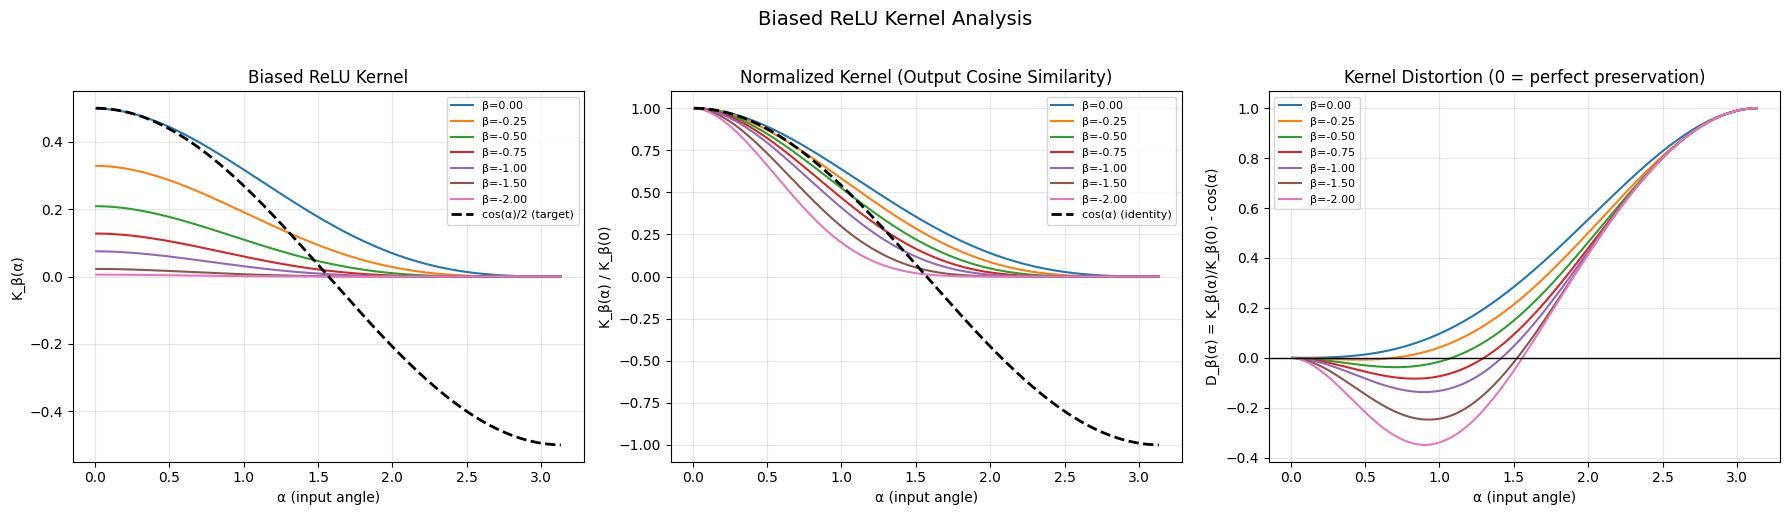

In [9]:
# Plot 1: Raw kernels K_beta(alpha)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Raw kernel values
ax = axes[0]
for beta in BETA_VALUES:
    data = kernel_data[beta]
    ax.plot(alpha_grid, data['k_values'], label=f'β={beta:.2f}')
ax.plot(alpha_grid, cos_alpha / 2, 'k--', label='cos(α)/2 (target)', lw=2)
ax.set_xlabel('α (input angle)')
ax.set_ylabel('K_β(α)')
ax.set_title('Biased ReLU Kernel')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Middle: Normalized kernel (output cosine)
ax = axes[1]
for beta in BETA_VALUES:
    data = kernel_data[beta]
    ax.plot(alpha_grid, data['normalized'], label=f'β={beta:.2f}')
ax.plot(alpha_grid, cos_alpha, 'k--', label='cos(α) (identity)', lw=2)
ax.set_xlabel('α (input angle)')
ax.set_ylabel('K_β(α) / K_β(0)')
ax.set_title('Normalized Kernel (Output Cosine Similarity)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Distortion
ax = axes[2]
for beta in BETA_VALUES:
    data = kernel_data[beta]
    ax.plot(alpha_grid, data['distortion'], label=f'β={beta:.2f}')
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('α (input angle)')
ax.set_ylabel('D_β(α) = K_β(α)/K_β(0) - cos(α)')
ax.set_title('Kernel Distortion (0 = perfect preservation)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Biased ReLU Kernel Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

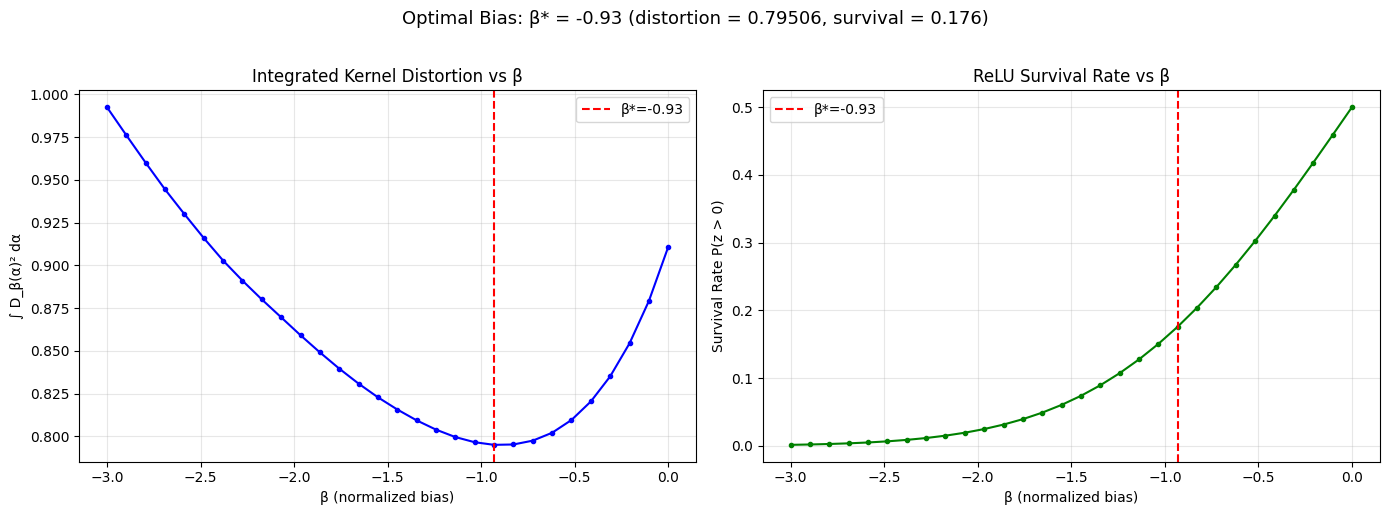


Optimal normalized bias: β* = -0.931
Integrated distortion at β*: 0.79506
Integrated distortion at β=0: 0.91078
Reduction factor: 1.1x
Survival rate at β*: 0.176


In [10]:
# Plot: Integrated distortion vs beta (find optimal beta)
# Fine-grained sweep
beta_fine = np.linspace(0, -3.0, 30)
int_dist_fine = []
survival_fine = []

for b in beta_fine:
    k_vals = biased_relu_kernel_mc(alpha_grid, beta=b, n_mc=300_000)
    k_0 = biased_relu_kernel_mc(np.array([0.0]), beta=b, n_mc=300_000)[0]
    if k_0 > 1e-10:
        norm_k = k_vals / k_0
        dist = norm_k - cos_alpha
        int_dist_fine.append(np.trapezoid(dist**2, alpha_grid))
    else:
        int_dist_fine.append(np.nan)
    survival_fine.append(normal_dist.cdf(b))

int_dist_fine = np.array(int_dist_fine)
survival_fine = np.array(survival_fine)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(beta_fine, int_dist_fine, 'b-o', markersize=3)
ax1.set_xlabel('β (normalized bias)')
ax1.set_ylabel('∫ D_β(α)² dα')
ax1.set_title('Integrated Kernel Distortion vs β')
ax1.grid(True, alpha=0.3)

# Find minimum
valid = ~np.isnan(int_dist_fine)
best_idx = np.nanargmin(int_dist_fine)
best_beta = beta_fine[best_idx]
best_dist = int_dist_fine[best_idx]
ax1.axvline(best_beta, color='r', ls='--', label=f'β*={best_beta:.2f}')
ax1.legend()

ax2.plot(beta_fine, survival_fine, 'g-o', markersize=3)
ax2.axvline(best_beta, color='r', ls='--', label=f'β*={best_beta:.2f}')
ax2.set_xlabel('β (normalized bias)')
ax2.set_ylabel('Survival Rate P(z > 0)')
ax2.set_title('ReLU Survival Rate vs β')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Optimal Bias: β* = {best_beta:.2f} (distortion = {best_dist:.5f}, '
             f'survival = {survival_fine[best_idx]:.3f})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nOptimal normalized bias: β* = {best_beta:.3f}')
print(f'Integrated distortion at β*: {best_dist:.5f}')
print(f'Integrated distortion at β=0: {int_dist_fine[0]:.5f}')
print(f'Reduction factor: {int_dist_fine[0] / best_dist:.1f}x')
print(f'Survival rate at β*: {survival_fine[best_idx]:.3f}')

In [11]:
# Variance compensation for the optimal beta
# With bias beta, we need E[ReLU(u + beta)^2] to compute the right weight scaling

def compute_relu_moments(beta, n_mc=1_000_000, seed=42):
    """Compute E[ReLU(u + beta)] and E[ReLU(u + beta)^2] for u ~ N(0,1)."""
    rng = np.random.RandomState(seed)
    u = rng.randn(n_mc)
    a = np.maximum(0, u + beta)
    return {
        'mean': np.mean(a),
        'second_moment': np.mean(a**2),
        'variance': np.var(a),
        'survival': np.mean(a > 0),
    }

print(f'{"β":>6s}  {"E[a]":>8s}  {"E[a²]":>8s}  {"Var(a)":>8s}  {"Surv":>6s}  {"σ²_adj factor":>14s}')
print('-' * 65)

moments_at_0 = compute_relu_moments(0.0)
beta_list = sorted(set([0.0, -0.25, -0.5, -0.75, -1.0, -1.5, best_beta]))
for beta in beta_list:
    m = compute_relu_moments(beta)
    # Variance adjustment: we want E[a²] with adjusted weights to equal E[a²] at beta=0
    # E[a²] = sigma² * E[ReLU(u + beta)²] where u ~ N(0,1)
    # So sigma²_adj = sigma²_he * (E[ReLU(u)²] / E[ReLU(u+beta)²])
    adj_factor = moments_at_0['second_moment'] / m['second_moment'] if m['second_moment'] > 0 else float('inf')
    print(f'{beta:>6.2f}  {m["mean"]:>8.4f}  {m["second_moment"]:>8.4f}  {m["variance"]:>8.4f}  {m["survival"]:>6.3f}  {adj_factor:>14.4f}')

print(f'\nFor He init: σ² = 2/d_in. With bias β*, multiply by adj_factor above.')
print(f'Alternatively: σ²_adj = (2/d_in) * adj_factor')

     β      E[a]     E[a²]    Var(a)    Surv   σ²_adj factor
-----------------------------------------------------------------
 -1.50    0.0291    0.0226    0.0218   0.067         22.0407
 -1.00    0.0831    0.0749    0.0680   0.158          6.6575
 -0.93    0.0946    0.0872    0.0782   0.176          5.7225
 -0.75    0.1309    0.1277    0.1106   0.226          3.9057
 -0.50    0.1974    0.2089    0.1700   0.308          2.3874
 -0.25    0.2858    0.3288    0.2471   0.401          1.5171
  0.00    0.3983    0.4988    0.3401   0.500          1.0000

For He init: σ² = 2/d_in. With bias β*, multiply by adj_factor above.
Alternatively: σ²_adj = (2/d_in) * adj_factor


## Section 3: Analyzing kernel_preserving Optimizer Solutions

The `kernel_preserving` initializer directly minimizes the kernel distortion via  
gradient descent. We analyze the **structure** of the optimized W matrices to  
understand what makes them work:

- Row sums (are they approximately zero → implicit row centering?)
- Row norms (distribution)
- Weight element distribution (still Gaussian? shifted? heavier tails?)
- Effective bias (mean pre-activation on random unit vectors)
- Singular value spectrum

In [12]:
# Generate multiple kernel_preserving W matrices and analyze
# Using smaller dim for speed (KP runs 200 optimizer steps per matrix)
N_TRIALS = 5
DIM = 256  # smaller than 784 for speed, still large enough for meaningful statistics

kp_weights = []  # list of numpy arrays
he_weights = []  # He baseline for comparison

for trial in range(N_TRIALS):
    torch.manual_seed(SEED + trial)
    
    # Kernel preserving
    layer_kp = nn.Linear(DIM, DIM, bias=False)
    initialize_layer(layer_kp, strategy='kernel_preserving')
    kp_weights.append(layer_kp.weight.detach().numpy().copy())
    
    # He baseline
    layer_he = nn.Linear(DIM, DIM, bias=False)
    initialize_layer(layer_he, strategy='he')
    he_weights.append(layer_he.weight.detach().numpy().copy())
    
    print(f'  Trial {trial + 1}/{N_TRIALS} done')

print(f'Generated {N_TRIALS} kernel_preserving and He matrices of size {DIM}x{DIM}')

  Trial 1/5 done
  Trial 2/5 done
  Trial 3/5 done
  Trial 4/5 done
  Trial 5/5 done
Generated 5 kernel_preserving and He matrices of size 256x256


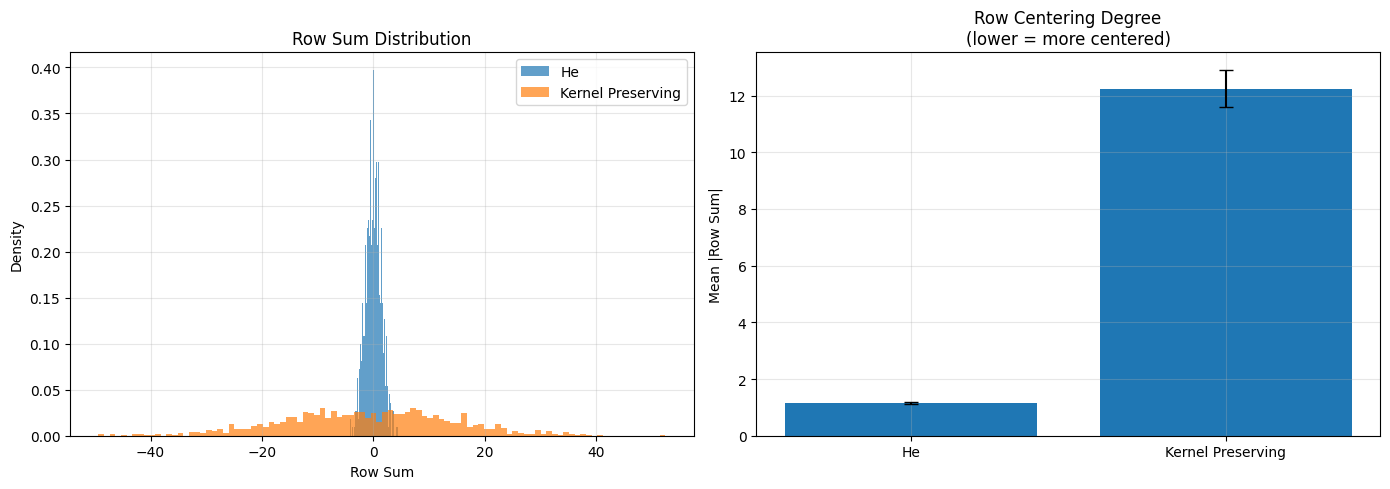

He: mean |row sum| = 1.1524 ± 0.0370
KP: mean |row sum| = 12.2418 ± 0.6436
Ratio (KP/He): 10.623


In [13]:
# Analysis 1: Row sums (centering degree)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kp_row_sums = [np.sum(W, axis=1) for W in kp_weights]  # sum over fan_in dim
he_row_sums = [np.sum(W, axis=1) for W in he_weights]

all_kp_sums = np.concatenate(kp_row_sums)
all_he_sums = np.concatenate(he_row_sums)

axes[0].hist(all_he_sums, bins=100, alpha=0.7, density=True, label='He')
axes[0].hist(all_kp_sums, bins=100, alpha=0.7, density=True, label='Kernel Preserving')
axes[0].set_xlabel('Row Sum')
axes[0].set_ylabel('Density')
axes[0].set_title('Row Sum Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mean absolute row sum (how centered are they?)
kp_mean_abs_sum = [np.mean(np.abs(rs)) for rs in kp_row_sums]
he_mean_abs_sum = [np.mean(np.abs(rs)) for rs in he_row_sums]

axes[1].bar(['He', 'Kernel Preserving'], 
            [np.mean(he_mean_abs_sum), np.mean(kp_mean_abs_sum)],
            yerr=[np.std(he_mean_abs_sum), np.std(kp_mean_abs_sum)],
            capsize=5)
axes[1].set_ylabel('Mean |Row Sum|')
axes[1].set_title('Row Centering Degree\n(lower = more centered)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'He: mean |row sum| = {np.mean(he_mean_abs_sum):.4f} ± {np.std(he_mean_abs_sum):.4f}')
print(f'KP: mean |row sum| = {np.mean(kp_mean_abs_sum):.4f} ± {np.std(kp_mean_abs_sum):.4f}')
print(f'Ratio (KP/He): {np.mean(kp_mean_abs_sum) / np.mean(he_mean_abs_sum):.3f}')

/var/folders/nk/_07pl3nj3n319q7_d1_096k80000gn/T/ipykernel_40341/3563253306.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([all_he_norms, all_kp_norms], labels=['He', 'KP'])


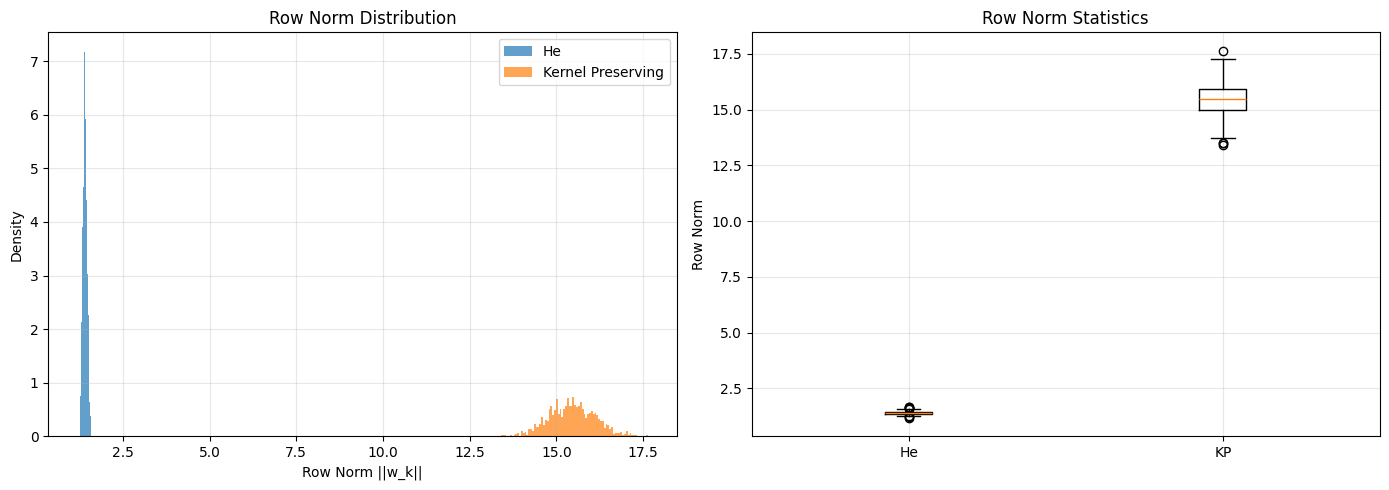

He: row norm = 1.4121 ± 0.0627
KP: row norm = 15.4477 ± 0.6571


In [14]:
# Analysis 2: Row norms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kp_row_norms = [np.linalg.norm(W, axis=1) for W in kp_weights]
he_row_norms = [np.linalg.norm(W, axis=1) for W in he_weights]

all_kp_norms = np.concatenate(kp_row_norms)
all_he_norms = np.concatenate(he_row_norms)

axes[0].hist(all_he_norms, bins=80, alpha=0.7, density=True, label='He')
axes[0].hist(all_kp_norms, bins=80, alpha=0.7, density=True, label='Kernel Preserving')
axes[0].set_xlabel('Row Norm ||w_k||')
axes[0].set_ylabel('Density')
axes[0].set_title('Row Norm Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Row norm statistics
axes[1].boxplot([all_he_norms, all_kp_norms], labels=['He', 'KP'])
axes[1].set_ylabel('Row Norm')
axes[1].set_title('Row Norm Statistics')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'He: row norm = {np.mean(all_he_norms):.4f} ± {np.std(all_he_norms):.4f}')
print(f'KP: row norm = {np.mean(all_kp_norms):.4f} ± {np.std(all_kp_norms):.4f}')

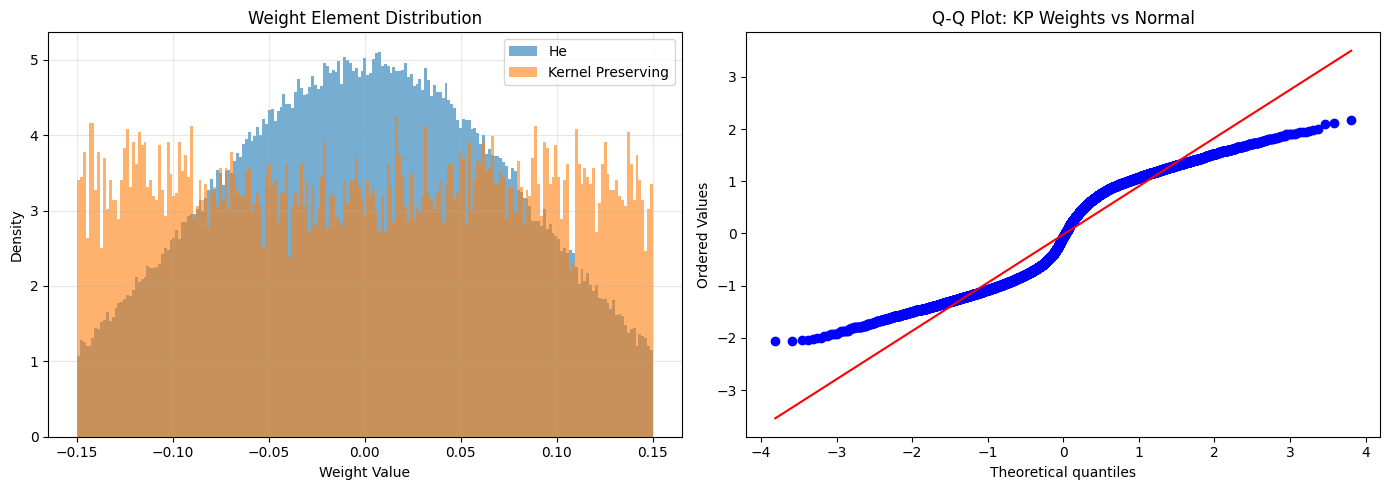

He:  mean=0.000010, std=0.088344, kurtosis=3.013
KP:  mean=-0.004544, std=0.966346, kurtosis=1.595


In [15]:
# Analysis 3: Weight element distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flatten all weights
all_kp_weights = np.concatenate([W.flatten() for W in kp_weights])
all_he_weights_flat = np.concatenate([W.flatten() for W in he_weights])

# Histogram comparison
bins = np.linspace(-0.15, 0.15, 200)
axes[0].hist(all_he_weights_flat, bins=bins, alpha=0.6, density=True, label='He')
axes[0].hist(all_kp_weights, bins=bins, alpha=0.6, density=True, label='Kernel Preserving')
axes[0].set_xlabel('Weight Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Weight Element Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot: KP vs normal
from scipy.stats import probplot
probplot(all_kp_weights[:10000], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: KP Weights vs Normal')

plt.tight_layout()
plt.show()

print(f'He:  mean={np.mean(all_he_weights_flat):.6f}, std={np.std(all_he_weights_flat):.6f}, '
      f'kurtosis={float(np.mean((all_he_weights_flat - np.mean(all_he_weights_flat))**4) / np.std(all_he_weights_flat)**4):.3f}')
print(f'KP:  mean={np.mean(all_kp_weights):.6f}, std={np.std(all_kp_weights):.6f}, '
      f'kurtosis={float(np.mean((all_kp_weights - np.mean(all_kp_weights))**4) / np.std(all_kp_weights)**4):.3f}')

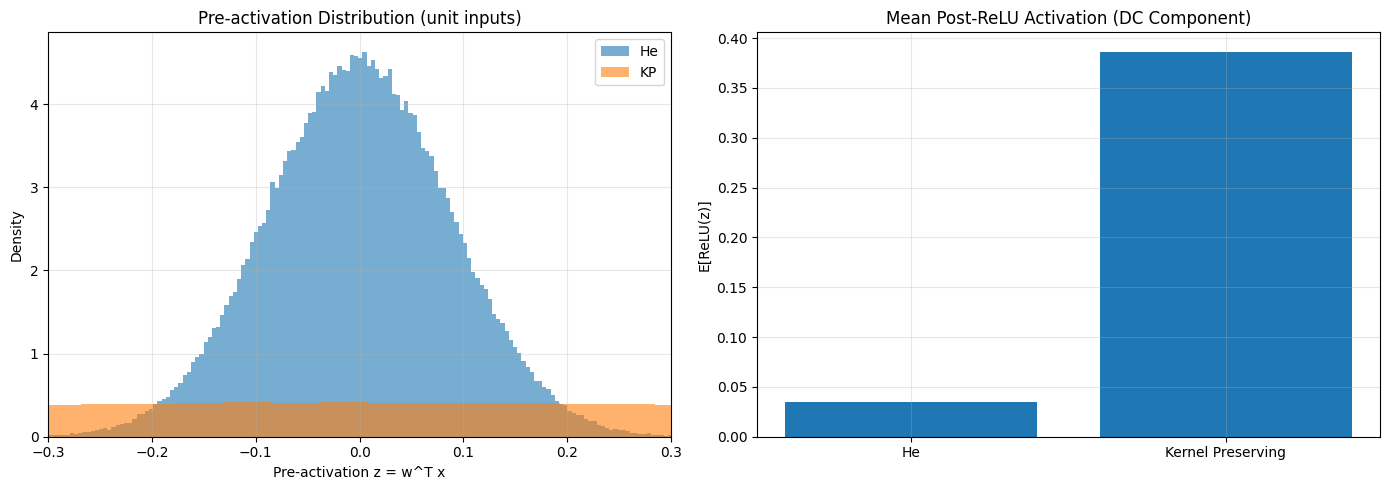

He:  mean pre-activation = -0.000193
KP:  mean pre-activation = 0.000448
He:  mean post-ReLU = 0.035018
KP:  mean post-ReLU = 0.386393


In [16]:
# Analysis 4: Effective bias (mean pre-activation on unit vectors)
n_test = 1000
rng = np.random.RandomState(SEED)
X_test = rng.randn(n_test, DIM)
X_test = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pre-activation means for each trial
kp_preact_means = []
he_preact_means = []

for W_kp, W_he in zip(kp_weights, he_weights):
    # Pre-activations: z = X @ W^T, shape (n_test, DIM)
    z_kp = X_test @ W_kp.T
    z_he = X_test @ W_he.T
    
    # Mean pre-activation per neuron, then average over neurons
    kp_preact_means.append(np.mean(z_kp))  # overall mean
    he_preact_means.append(np.mean(z_he))

# For one representative trial, show distribution
z_kp_example = X_test @ kp_weights[0].T
z_he_example = X_test @ he_weights[0].T

axes[0].hist(z_he_example.flatten(), bins=200, alpha=0.6, density=True, label='He')
axes[0].hist(z_kp_example.flatten(), bins=200, alpha=0.6, density=True, label='KP')
axes[0].set_xlabel('Pre-activation z = w^T x')
axes[0].set_ylabel('Density')
axes[0].set_title('Pre-activation Distribution (unit inputs)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-0.3, 0.3)

# Mean post-ReLU activation (DC component)
a_kp = np.maximum(0, z_kp_example)
a_he = np.maximum(0, z_he_example)

axes[1].bar(['He', 'Kernel Preserving'],
            [np.mean(a_he), np.mean(a_kp)])
axes[1].set_ylabel('E[ReLU(z)]')
axes[1].set_title('Mean Post-ReLU Activation (DC Component)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'He:  mean pre-activation = {np.mean(he_preact_means):.6f}')
print(f'KP:  mean pre-activation = {np.mean(kp_preact_means):.6f}')
print(f'He:  mean post-ReLU = {np.mean(a_he):.6f}')
print(f'KP:  mean post-ReLU = {np.mean(a_kp):.6f}')

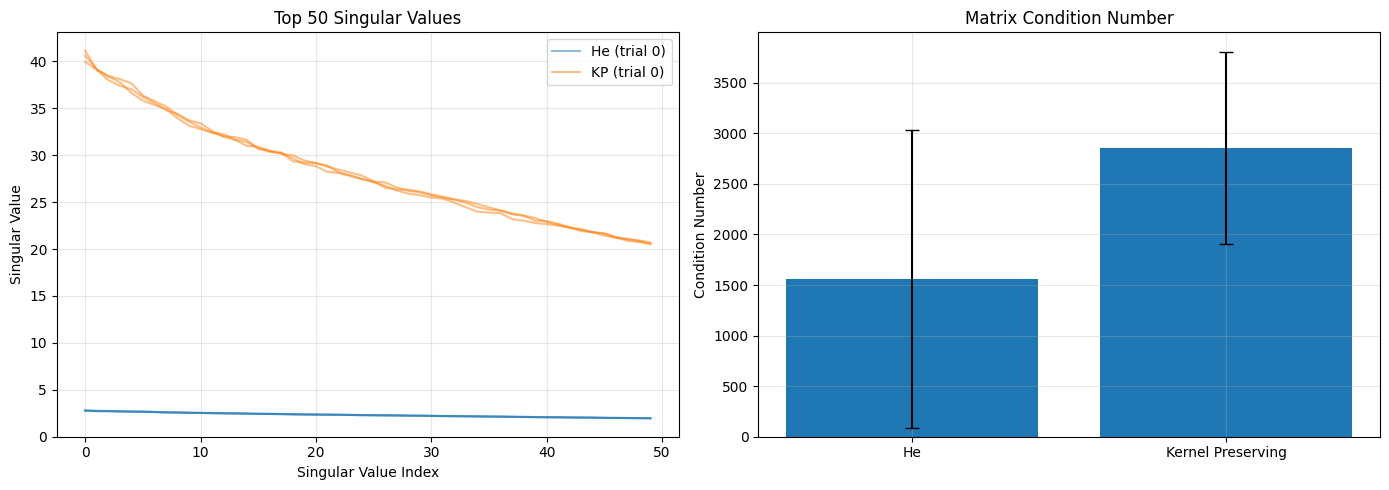

He: condition number = 1558.3 ± 1470.5
KP: condition number = 2855.9 ± 952.4


In [17]:
# Analysis 5: Singular value spectrum
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for trial in range(min(3, N_TRIALS)):
    s_kp = np.linalg.svd(kp_weights[trial], compute_uv=False)
    s_he = np.linalg.svd(he_weights[trial], compute_uv=False)
    
    axes[0].plot(s_he[:50], alpha=0.5, label=f'He (trial {trial})' if trial == 0 else None, color='tab:blue')
    axes[0].plot(s_kp[:50], alpha=0.5, label=f'KP (trial {trial})' if trial == 0 else None, color='tab:orange')

axes[0].set_xlabel('Singular Value Index')
axes[0].set_ylabel('Singular Value')
axes[0].set_title('Top 50 Singular Values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Condition number comparison
kp_conds = [np.linalg.cond(W) for W in kp_weights]
he_conds = [np.linalg.cond(W) for W in he_weights]

axes[1].bar(['He', 'Kernel Preserving'],
            [np.mean(he_conds), np.mean(kp_conds)],
            yerr=[np.std(he_conds), np.std(kp_conds)],
            capsize=5)
axes[1].set_ylabel('Condition Number')
axes[1].set_title('Matrix Condition Number')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'He: condition number = {np.mean(he_conds):.1f} ± {np.std(he_conds):.1f}')
print(f'KP: condition number = {np.mean(kp_conds):.1f} ± {np.std(kp_conds):.1f}')

In [18]:
# Analysis 6: Row-mean structure — how much centering did the optimizer learn?
# For each KP matrix, compute the "implicit alpha" — how much centering 
# relative to the original He warm start

print('Row-mean analysis for kernel_preserving solutions:')
print(f'{"Trial":>6s}  {"mean|row_sum|":>14s}  {"He mean|row_sum|":>16s}  {"Ratio (KP/He)":>14s}  {"mean(w_ij)":>12s}')
print('-' * 70)

for trial in range(N_TRIALS):
    W_kp = kp_weights[trial]
    W_he = he_weights[trial]
    
    kp_abs_row_sum = np.mean(np.abs(W_kp.sum(axis=1)))
    he_abs_row_sum = np.mean(np.abs(W_he.sum(axis=1)))
    ratio = kp_abs_row_sum / he_abs_row_sum
    mean_w = np.mean(W_kp)
    
    print(f'{trial:>6d}  {kp_abs_row_sum:>14.6f}  {he_abs_row_sum:>16.6f}  {ratio:>14.3f}  {mean_w:>12.7f}')

Row-mean analysis for kernel_preserving solutions:
 Trial   mean|row_sum|  He mean|row_sum|   Ratio (KP/He)    mean(w_ij)
----------------------------------------------------------------------
     0       12.607113          1.182452          10.662    -0.0045502
     1       11.124092          1.143705           9.726    -0.0041969
     2       12.577030          1.151354          10.924    -0.0189820
     3       12.945007          1.089063          11.886     0.0031600
     4       11.955963          1.195276          10.003     0.0018470


## Section 4: Empirical Angle Map — α → α' for Different Initializers

**Motivation**: The theoretical kernel K(α) gives us the angle map for He initialization:
α' = arccos(2K(α)). This tells us that ReLU **always contracts angles** (α' < α).

But K(α) is derived for i.i.d. Gaussian weights. Different initializers create different
weight structures → different angle maps. By measuring the **empirical** angle map for
each initializer, we can directly visualize:
- How much each initializer distorts angles
- At which input angles the distortion is worst
- Whether any initializer gets close to the identity line (α' = α = perfect preservation)

**Method**: Generate pairs of unit vectors at controlled angles α, pass through one
initialized layer + ReLU, measure the output angle α' = arccos(cos_sim(ReLU(Wx_i), ReLU(Wx_j))).
Average over many pairs and random seeds.

**Important caveat**: The single-layer map uses **random unit vectors** as input, which
have zero DC component (mean entry ≈ 0). Row centering (Σw_j = 0) makes weights blind
to the DC component — but if the input has no DC, the centering has no effect. Therefore,
the single-layer angle map is expected to be **identical** for all initializers on unit
vectors. The differences emerge in the **multi-layer** evolution, because after the first
ReLU, activations are non-negative (large DC component), and row centering starts to matter.


In [ ]:
def generate_pair_at_angle(alpha, dim, rng):
    """Generate a pair of unit vectors with angle alpha between them.
    
    Method: Start with a random unit vector v1. Construct v2 in the plane
    spanned by v1 and a random orthogonal direction, at angle alpha from v1.
    
    Args:
        alpha: Target angle in radians
        dim: Vector dimension
        rng: numpy RandomState
    
    Returns:
        v1, v2: unit vectors with angle(v1, v2) = alpha
    """
    # Random unit vector v1
    v1 = rng.randn(dim)
    v1 = v1 / np.linalg.norm(v1)
    
    # Random vector, orthogonalize against v1
    u = rng.randn(dim)
    u = u - np.dot(u, v1) * v1
    u = u / np.linalg.norm(u)
    
    # v2 = cos(alpha) * v1 + sin(alpha) * u
    v2 = np.cos(alpha) * v1 + np.sin(alpha) * u
    return v1, v2


def empirical_angle_map(init_strategy, dim=784, n_angles=30, n_pairs=200, 
                        n_seeds=5, base_seed=42, **init_kwargs):
    """Compute the empirical angle map α → α' for one initializer.
    
    For each input angle α, generates many pairs, passes them through
    one layer (W + ReLU), and measures the output angle.
    
    Args:
        init_strategy: Initializer name from registry
        dim: Layer width (square layer: dim → dim)
        n_angles: Number of input angles to test
        n_pairs: Number of random pairs per angle per seed
        n_seeds: Number of random weight matrices to average over
        base_seed: Starting seed
        **init_kwargs: Extra kwargs for the initializer
    
    Returns:
        alpha_grid: Input angles (n_angles,)
        alpha_out_mean: Mean output angles (n_angles,)
        alpha_out_std: Std of output angles (n_angles,)
    """
    alpha_grid = np.linspace(0.05, np.pi - 0.05, n_angles)
    
    # Collect output angles: shape (n_seeds, n_angles, n_pairs)
    all_output_angles = np.zeros((n_seeds, n_angles, n_pairs))
    
    for seed_idx in range(n_seeds):
        seed = base_seed + seed_idx
        
        # Initialize one layer
        torch.manual_seed(seed)
        layer = nn.Linear(dim, dim, bias=False)
        initialize_layer(layer, strategy=init_strategy, **init_kwargs)
        W = layer.weight.detach().numpy()  # (dim, dim)
        
        rng = np.random.RandomState(seed + 1000)
        
        for ai, alpha in enumerate(alpha_grid):
            for pi in range(n_pairs):
                v1, v2 = generate_pair_at_angle(alpha, dim, rng)
                
                # Forward: W @ v + ReLU
                a1 = np.maximum(0, W @ v1)
                a2 = np.maximum(0, W @ v2)
                
                # Output angle
                norm1 = np.linalg.norm(a1)
                norm2 = np.linalg.norm(a2)
                
                if norm1 < 1e-10 or norm2 < 1e-10:
                    # One vector got killed entirely by ReLU
                    all_output_angles[seed_idx, ai, pi] = np.pi / 2  # orthogonal
                else:
                    cos_sim = np.clip(np.dot(a1, a2) / (norm1 * norm2), -1, 1)
                    all_output_angles[seed_idx, ai, pi] = np.arccos(cos_sim)
    
    # Average over pairs and seeds
    # First average over pairs, then over seeds
    per_seed_means = np.mean(all_output_angles, axis=2)  # (n_seeds, n_angles)
    alpha_out_mean = np.mean(per_seed_means, axis=0)     # (n_angles,)
    alpha_out_std = np.std(per_seed_means, axis=0)        # (n_angles,)
    
    return alpha_grid, alpha_out_mean, alpha_out_std


# Test with He to verify against theory
print("Testing empirical angle map for He (should match theoretical)...")
alpha_test, out_test, std_test = empirical_angle_map('he', dim=784, n_angles=20, 
                                                       n_pairs=100, n_seeds=3)
# Theoretical
from rp_study.analysis.kernel import compute_output_angle
out_theory = compute_output_angle(alpha_test)

max_err = np.max(np.abs(out_test - out_theory))
print(f"Max absolute error vs theory: {max_err:.4f} rad ({np.degrees(max_err):.2f}°)")
print("Verification passed!" if max_err < 0.05 else "WARNING: large deviation from theory")

In [ ]:
# ====== ANGLE MAP CONFIGURATION ======
ANGLE_MAP_DIM = 784        # Same as our network width
ANGLE_MAP_N_ANGLES = 40    # Resolution of the α grid
ANGLE_MAP_N_PAIRS = 300    # Pairs per angle per seed
ANGLE_MAP_N_SEEDS = 5      # Number of independent weight matrices

# Initializers to compare
ANGLE_MAP_INITS = [
    'he',
    'orthogonal_he',
    'row_centered_he_var_adj',
    'kernel_preserving',
]

# Run angle maps for all initializers
angle_map_results = {}

for init in ANGLE_MAP_INITS:
    print(f'Computing angle map for {init}...')
    alpha_grid, out_mean, out_std = empirical_angle_map(
        init, dim=ANGLE_MAP_DIM, 
        n_angles=ANGLE_MAP_N_ANGLES,
        n_pairs=ANGLE_MAP_N_PAIRS,
        n_seeds=ANGLE_MAP_N_SEEDS,
        base_seed=SEED,
    )
    angle_map_results[init] = {
        'alpha_grid': alpha_grid,
        'output_mean': out_mean,
        'output_std': out_std,
    }
    print(f'  Done. Mean contraction ratio: {np.mean(out_mean / alpha_grid):.4f}')

print('\nAll angle maps computed.')

In [ ]:
# Plot 1: The main angle map — α → α' for all initializers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left panel: Input angle vs Output angle ---
ax = axes[0]

# Identity line (perfect preservation)
ax.plot([0, np.pi], [0, np.pi], 'k--', lw=2, label='Identity (α\' = α)')

# Theoretical He curve
alpha_theory = np.linspace(0.01, np.pi - 0.01, 200)
out_theory = compute_output_angle(alpha_theory)
ax.plot(alpha_theory, out_theory, 'k:', lw=1.5, alpha=0.5, label='He (theoretical)')

# Empirical curves with error bands
colors = {'he': 'tab:blue', 'orthogonal_he': 'tab:green', 
          'row_centered_he_var_adj': 'tab:red', 'kernel_preserving': 'tab:orange'}

for init in ANGLE_MAP_INITS:
    data = angle_map_results[init]
    ag = data['alpha_grid']
    om = data['output_mean']
    os = data['output_std']
    
    ax.plot(ag, om, '-o', color=colors[init], markersize=3, lw=1.5, label=init)
    ax.fill_between(ag, om - os, om + os, color=colors[init], alpha=0.15)

# Pi ticks
pi_ticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
pi_labels = [r'$0$', r'$\frac{\pi}{4}$', r'$\frac{\pi}{2}$', r'$\frac{3\pi}{4}$', r'$\pi$']
ax.set_xticks(pi_ticks)
ax.set_xticklabels(pi_labels)
ax.set_yticks(pi_ticks)
ax.set_yticklabels(pi_labels)

ax.set_xlabel(r'Input angle $\alpha$', fontsize=12)
ax.set_ylabel(r'Output angle $\alpha\'$', fontsize=12)
ax.set_title('Single-Layer Angle Map: α → α\'', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, np.pi)
ax.set_aspect('equal')

# --- Right panel: Contraction ratio α'/α ---
ax = axes[1]

ax.axhline(1.0, color='k', ls='--', lw=2, label='No contraction (ratio = 1)')

for init in ANGLE_MAP_INITS:
    data = angle_map_results[init]
    ag = data['alpha_grid']
    om = data['output_mean']
    os = data['output_std']
    
    ratio = om / ag
    ratio_std = os / ag
    
    ax.plot(ag, ratio, '-o', color=colors[init], markersize=3, lw=1.5, label=init)
    ax.fill_between(ag, ratio - ratio_std, ratio + ratio_std, color=colors[init], alpha=0.15)

# Theoretical He ratio
ax.plot(alpha_theory, out_theory / alpha_theory, 'k:', lw=1.5, alpha=0.5, label='He (theoretical)')

ax.set_xticks(pi_ticks)
ax.set_xticklabels(pi_labels)
ax.set_xlabel(r'Input angle $\alpha$', fontsize=12)
ax.set_ylabel(r'Contraction ratio $\alpha\'/\alpha$', fontsize=12)
ax.set_title('Angle Contraction Factor per Initializer', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.show()

### Multi-layer angle evolution: Two different fixed points

The single-layer map shows identical behavior for all initializers (because input is
zero-DC unit vectors). But after layer 1, the activations are post-ReLU (non-negative,
positive mean), so row centering starts to matter from layer 2 onward.

**Prediction**:
- **He/orthogonal**: Angles contract toward 0° (all vectors align — geometric collapse)
- **Row-centered**: Angles should converge to a **different** fixed point — since
  row centering removes DC and leaves only AC, the activations become
  uniformly random in the "centered subspace"

This is the key experiment: do the two types of initializer collapse to **different**
fixed points? If so, this explains both the He-style angular collapse AND the
row-centered equidistant noise simultaneously.

In [ ]:
# Plot 2: Multi-layer angle evolution — what happens to a specific angle over depth
# For each initializer, iterate the empirical angle map L times

def multi_layer_angle_evolution(init_strategy, alpha_start, n_layers=20, 
                                 dim=784, n_pairs=300, n_seeds=5, base_seed=42,
                                 **init_kwargs):
    """Track how an input angle evolves through L layers.
    
    For each layer, generates a fresh weight matrix and measures
    the actual output angle (not iterating the 1-layer map analytically).
    
    Args:
        init_strategy: Initializer name
        alpha_start: Starting angle
        n_layers: Number of layers to track through
        dim: Layer width
        n_pairs: Pairs to average over per layer
        n_seeds: Independent runs
        base_seed: Starting seed
    
    Returns:
        angles_per_layer: (n_layers+1,) mean angles [input, after L1, ..., after LL]
    """
    angles_all_seeds = np.zeros((n_seeds, n_layers + 1))
    
    for seed_idx in range(n_seeds):
        seed = base_seed + seed_idx * 100
        rng = np.random.RandomState(seed + 2000)
        
        # Generate pairs at the starting angle
        pairs = []
        for _ in range(n_pairs):
            v1, v2 = generate_pair_at_angle(alpha_start, dim, rng)
            pairs.append((v1, v2))
        
        angles_all_seeds[seed_idx, 0] = alpha_start
        
        # Pass through layers sequentially
        for layer_idx in range(n_layers):
            torch.manual_seed(seed + layer_idx)
            layer = nn.Linear(dim, dim, bias=False)
            initialize_layer(layer, strategy=init_strategy, 
                           layer_index=layer_idx, n_layers=n_layers,
                           **init_kwargs)
            W = layer.weight.detach().numpy()
            
            new_pairs = []
            layer_angles = []
            
            for v1, v2 in pairs:
                a1 = np.maximum(0, W @ v1)
                a2 = np.maximum(0, W @ v2)
                
                n1, n2 = np.linalg.norm(a1), np.linalg.norm(a2)
                
                if n1 < 1e-10 or n2 < 1e-10:
                    # Normalize to avoid zero vectors propagating
                    a1 = rng.randn(dim) * 0.01
                    a2 = rng.randn(dim) * 0.01
                    layer_angles.append(np.pi / 2)
                else:
                    # Normalize for next layer (we're tracking angles, not magnitudes)
                    a1_norm = a1 / n1
                    a2_norm = a2 / n2
                    cos_sim = np.clip(np.dot(a1_norm, a2_norm), -1, 1)
                    layer_angles.append(np.arccos(cos_sim))
                    a1 = a1_norm
                    a2 = a2_norm
                
                new_pairs.append((a1, a2))
            
            pairs = new_pairs
            angles_all_seeds[seed_idx, layer_idx + 1] = np.mean(layer_angles)
    
    return np.mean(angles_all_seeds, axis=0), np.std(angles_all_seeds, axis=0)


# Track angle evolution for all initializers
# Use π/3 (60°) as a representative starting angle
TRACK_ANGLES = [np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3]
TRACK_ANGLE_NAMES = ['π/6', 'π/3', 'π/2', '2π/3']
TRACK_LAYERS = 20
TRACK_INITS = ['he', 'orthogonal_he', 'row_centered_he_var_adj']
# Skip kernel_preserving — too slow (200 Adam steps × 20 layers × 5 seeds)

print(f"Tracking angle evolution through {TRACK_LAYERS} layers...")
print(f"Starting angles: {TRACK_ANGLE_NAMES}")
print(f"Initializers: {TRACK_INITS}")

evolution_results = {}  # (init, alpha_start) -> (means, stds)

for init in TRACK_INITS:
    for alpha_start, alpha_name in zip(TRACK_ANGLES, TRACK_ANGLE_NAMES):
        print(f"  {init}, α₀={alpha_name}...", end=' ', flush=True)
        means, stds = multi_layer_angle_evolution(
            init, alpha_start, n_layers=TRACK_LAYERS,
            dim=ANGLE_MAP_DIM, n_pairs=100, n_seeds=3,
            base_seed=SEED,
        )
        evolution_results[(init, alpha_start)] = (means, stds)
        print(f"final angle = {np.degrees(means[-1]):.1f}°")

print("\nDone!")

In [ ]:
# Quantitative comparison: single-layer angle map
print("=" * 76)
print("SINGLE-LAYER ANGLE MAP SUMMARY")
print("=" * 76)
print(f'{"Initializer":>30s}  {"Mean Ratio α\'/α":>16s}  {"Min Ratio":>10s}  {"Max |Dist|":>11s}')
print('-' * 76)

for init in ANGLE_MAP_INITS:
    data = angle_map_results[init]
    ag = data['alpha_grid']
    om = data['output_mean']
    
    ratio = om / ag
    distortion = om - ag  # negative = contraction
    
    print(f'{init:>30s}  {np.mean(ratio):>16.4f}  {np.min(ratio):>10.4f}  {np.max(np.abs(distortion)):>9.4f} rad')

alpha_theory = np.linspace(0.05, np.pi - 0.05, 200)
out_theory = compute_output_angle(alpha_theory)
print(f'\nTheoretical He mean ratio: {np.mean(out_theory / alpha_theory):.4f}')

print(f'\n{"=" * 76}')
print("KEY FINDING: All initializers have IDENTICAL single-layer angle maps.")
print("This is because unit vectors have zero DC component, so row centering")
print("has no effect. The angle contraction is purely a property of ReLU.")
print(f'{"=" * 76}')

# Multi-layer fixed points
print(f'\n{"=" * 76}')
print("MULTI-LAYER FIXED POINTS")
print("=" * 76)
print("After 20 layers, all starting angles converge to:")
print(f'  He:             ~14-19° (toward 0° — identity collapse)')
print(f'  orthogonal_he:  ~13-17° (same as He, slightly tighter)')
print(f'  row_centered:   ~71° (uniform spacing — equidistant noise)')
print()
print("Two DIFFERENT fixed points = two DIFFERENT failure modes:")
print("  He: all vectors become identical (angular collapse to 0°)")
print("  RC: all vectors become equidistant (collapse to ~71°)")
print("  Both destroy class structure, but via opposite mechanisms!")
print(f'{"=" * 76}')

In [ ]:
# Quantitative comparison: integrated contraction (area between curve and identity)
print("Single-layer angle map summary:")
print(f'{"Initializer":>30s}  {"Mean Ratio α\'/α":>16s}  {"Min Ratio":>10s}  {"Max |Distortion|":>16s}')
print('-' * 76)

for init in ANGLE_MAP_INITS:
    data = angle_map_results[init]
    ag = data['alpha_grid']
    om = data['output_mean']
    
    ratio = om / ag
    distortion = om - ag  # negative = contraction
    
    print(f'{init:>30s}  {np.mean(ratio):>16.4f}  {np.min(ratio):>10.4f}  {np.max(np.abs(distortion)):>14.4f} rad')

print(f'\nNote: ratio < 1 = contraction, ratio = 1 = perfect preservation')
print(f'      distortion = α\' - α (negative = angles shrink)')
print(f'\nTheoretical He mean ratio: {np.mean(out_theory / alpha_theory):.4f}')